In [1]:
# Imports
import numpy as np
from scipy.linalg import eig
import matplotlib.pyplot as plt


In [2]:
# Array of r values
R = 1.0
N = 1000    # keep same domain extent r_max = 50
dr = R/N
r_values = np.arange(1, N+1) * dr + 0.01

# Defining constants
U = 1
H = 1
k = np.ones(N)
v_parallel = 1

# Equilibrium pressure and potential
phi_0 = np.exp(-r_values**2 / 0.3**2)        # Gaussian, peaks at r=0
p_0   = np.exp(-r_values**2 / 0.3**2)        # same shape, adjust 0.3 to control width

# Which mode
m = 1

# Matrix Helper Functions

In [3]:
def create_first_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i-1] = -1

    matrix[0][0] = -3 
    matrix[0][1] = 4
    matrix[0][2] = -1

    matrix[N_-1][N_-3] = 1 
    matrix[N_-1][N_-2] = -4
    matrix[N_-1][N_-1] = 3

    return matrix / (2 * dr_)

def create_second_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(1, N_-1, 1):
        matrix[i][i+1] = 1 
        matrix[i][i] = -2
        matrix[i][i-1] = 1

    matrix[0][0] = 2
    matrix[0][1] = -5
    matrix[0][2] = 4
    matrix[0][3] = -1

    matrix[N_-1][N_-4] = -1
    matrix[N_-1][N_-3] = 4
    matrix[N_-1][N_-2] = -5
    matrix[N_-1][N_-1] = 2

    return matrix / (dr_ ** 2)

def create_third_derivative_matrix(N_, dr_):
    matrix = np.zeros((N_,N_))

    for i in range(2, N_-2, 1):
        matrix[i][i-2] = -1
        matrix[i][i-1] = 2
        matrix[i][i+1] = -2
        matrix[i][i+2] = 1

    matrix[0][0] = -5
    matrix[0][1] = 18
    matrix[0][2] = -24
    matrix[0][3] = 14
    matrix[0][4] = -3

    matrix[N_-1][N_-1] = 5
    matrix[N_-1][N_-2] = -18
    matrix[N_-1][N_-3] = 24
    matrix[N_-1][N_-4] = -14
    matrix[N_-1][N_-5] = 3

    matrix[1][0] = -3
    matrix[1][1] = 10
    matrix[1][2] = -12
    matrix[1][3] = 6
    matrix[1][4] = -1

    matrix[N_-2][N_-1] = 3
    matrix[N_-2][N_-2] = -10
    matrix[N_-2][N_-3] = 12
    matrix[N_-2][N_-4] = -6
    matrix[N_-2][N_-5] = 1

    return (matrix / (2 * (dr_ ** 3)))

def create_m_laplacian(N_, dr_, m_, r_values_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)

    return (
        D2
        + np.diag(1 / r_values_) @ D1
        - np.diag(m_**2 / (r_values_**2))
    )

def enforce_bc(A_, B_, N_):
    A_[N_-1][:] = 0
    B_[N_-1][:] = 0
    B_[N_-1][N_-1] = 1

    B_[0][:] = 0
    B_[0][0] = 1
    A_[0][:] = 0

    B_[N_][:] = 0
    B_[N_][N_] = 1
    A_[N_][:] = 0

    return A_, B_

def create_A_and_B(N_, dr_, m_, r_values_, phi_0_, p_0_, v_parallel_, H_, k_, U_):
    D1 = create_first_derivative_matrix(N_, dr_)
    D2 = create_second_derivative_matrix(N_, dr_)
    D3 = create_third_derivative_matrix(N_, dr_)
    Dm = create_m_laplacian(N_, dr_, m_, r_values_)

    diag_div_r = np.diag(1 / r_values_)

    omega_0_diag = diag_div_r @ np.diag(D1 @ phi_0_)
    D_phi_prime_diag = np.diag((D3 + diag_div_r @ D2 - np.diag(1 / (r_values_ ** 2)) @ D1) @ phi_0_)

    L11 = (-1j * m_ * omega_0_diag @ Dm 
        + 1j * m_ * diag_div_r @ D_phi_prime_diag 
        - 1j * m_ * U_ * diag_div_r @ (np.diag(D2 @ p_0_) @ D1 + np.diag(D1 @ p_0_) @ D2) 
        + 1j * (m_ ** 3) * U_ * np.diag(1 / (r_values_ ** 3)) @ np.diag(D1 @ p_0_) 
        + np.diag(np.ones(N_) * H_) 
        - v_parallel_ * Dm)

    L12 = 1j * m_ * U_ * diag_div_r @ (np.diag(D3 @ phi_0_) + np.diag(D2 @ phi_0_) @ D1) - 2j * m_ * np.diag(k_)
    L21 = 1j * m_ * np.diag(1 / r_values_) @ np.diag(D1 @ p_0_)
    L22 = -np.diag(np.ones(N_) * v_parallel_) - (1j * m_ * omega_0_diag)

    A = np.block([
        [Dm, np.zeros((N_,N_))],
        [np.zeros((N_,N_)), np.eye(N_)]
    ])

    B = np.block([
        [L11, L12],
        [L21, L22]
    ])

    A, B = enforce_bc(A, B, N_)

    return A, B

## Linear Stability Operator

The eigenvalue problem to be solved is:

$$
\gamma
\begin{pmatrix} \Delta_m & 0 \\ 0 & 1 \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}
=
\begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} \\ \mathcal{L}_{21} & \mathcal{L}_{22} \end{pmatrix}
\begin{pmatrix} \hat\varphi \\ \hat\rho \end{pmatrix}.
$$

### Linear operators (expanded form)

$$
\mathcal{L}_{11}
  = -im\Omega_0 \Delta_m
    + \frac{im}{r}(\Delta\varphi_0)'
    - \frac{imU}{r}\left(P_0''\frac{\partial}{\partial r} + P_0'\,\frac{\partial^2}{\partial r^2}\right)
    + \frac{im^3 U}{r^3}\,P_0'
    + H
    - \nu_\parallel \Delta_m,
$$

$$
\mathcal{L}_{12}
  = \frac{imU}{r}\left(\varphi_0''' + \varphi_0''\,\frac{\partial}{\partial r}\right) - 2im\mathcal{K},
$$

$$
\mathcal{L}_{21} = \frac{im}{r}P_0'(r),
$$

$$
\mathcal{L}_{22} = -\nu_\parallel^P - im\Omega_0(r).
$$

where
$$\Omega_0(r) \equiv \frac{1}{r}\frac{\partial \varphi_0}{\partial r}, \quad \text{where } \varphi_0 \text{ is the equilibrium potential.}$$

and 

$$
(\Delta\varphi_0)' = \varphi_0''' + \frac{\varphi_0''}{r} - \frac{\varphi_0'}{r^2}.
$$

In [ ]:
A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, k, U)

eigenvalues, eigenvectors = eig(B, A)

# Each column of eigenvectors is an eigenvector
x0 = eigenvectors[:, 0]  # eigenvector for eigenvalues[0]

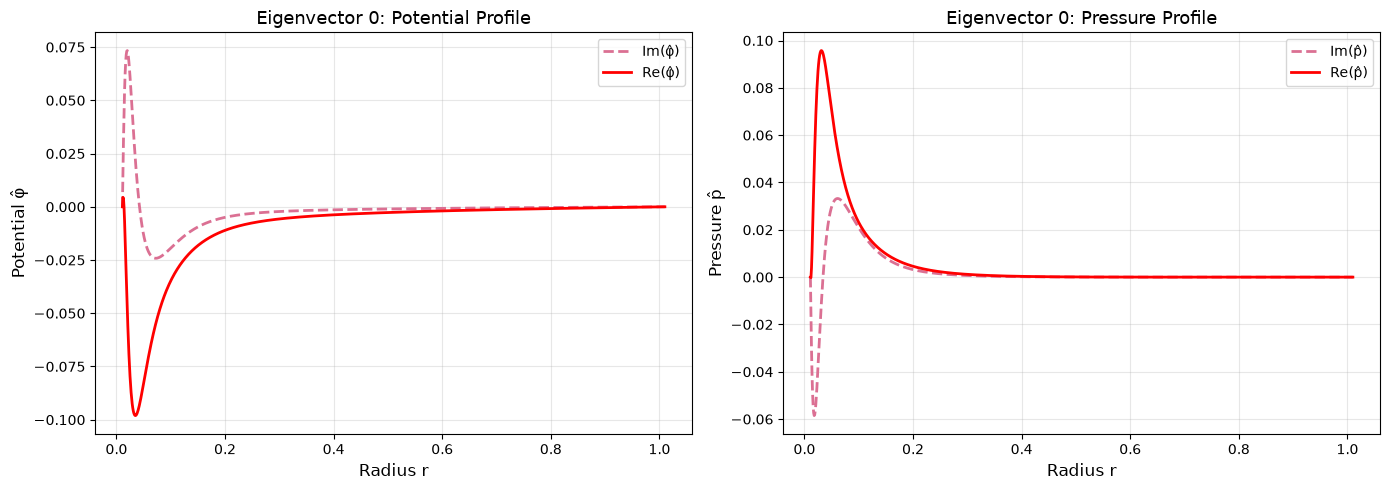

In [5]:
# Eigenvalue for null space vectors are inf, so we only look at the finite eigenvalues
finite_mask = np.isfinite(eigenvalues)
finite_evals = eigenvalues[finite_mask]
finite_indices = np.where(finite_mask)[0]
eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]

eigenvector = eigenvectors[:, eigenvector_index]
potential = eigenvector[:N]
pressure = eigenvector[N:2*N]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot potential
ax1.plot(r_values, np.imag(potential), '--', linewidth=2, label='Im(φ̂)', color='palevioletred')
ax1.plot(r_values, np.real(potential), linewidth=2, label='Re(φ̂)', color='red')
ax1.set_xlabel('Radius r', fontsize=12)
ax1.set_ylabel('Potential φ̂', fontsize=12)
ax1.set_title(f'Eigenvector {eigenvector_index}: Potential Profile', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot pressure
ax2.plot(r_values, np.imag(pressure), '--', linewidth=2, label='Im(p̂)', color='palevioletred')
ax2.plot(r_values, np.real(pressure), linewidth=2, label='Re(p̂)', color='red')
ax2.set_xlabel('Radius r', fontsize=12)
ax2.set_ylabel('Pressure p̂', fontsize=12)
ax2.set_title(f'Eigenvector {eigenvector_index}: Pressure Profile', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

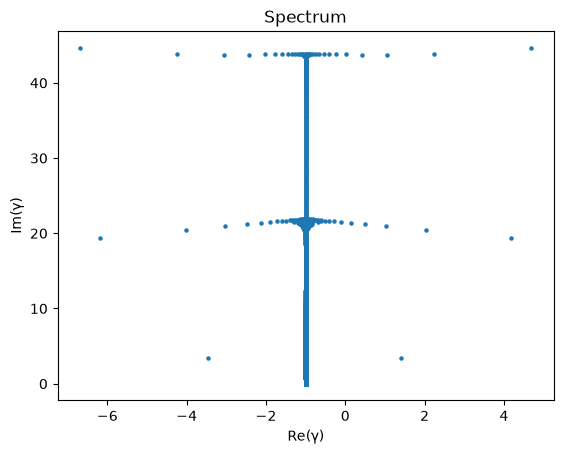

In [6]:
plt.scatter(np.real(finite_evals), np.imag(finite_evals), s=5)
plt.xlabel("Re(γ)"); plt.ylabel("Im(γ)")
plt.title("Spectrum")
plt.show()

In [7]:
np.max(np.real(finite_evals))

np.float64(4.683946734213334)

# Testing eigenvalue convergence

In [7]:
N_vals = [10, 50, 100, 200, 400, 800, 1600, 3200]
eigenvalues_list = np.zeros(len(N_vals))
eigenvectors_list = [None] * len(N_vals)

for i, N in enumerate(N_vals):

    print(N)

    dr = R/N
    r_values = np.arange(1, N+1) * dr + 0.01    
    k = np.ones(N)
    phi_0 = np.exp(-r_values**2 / 0.3**2)        # Gaussian, peaks at r=0
    p_0   = np.exp(-r_values**2 / 0.3**2)        # same shape, adjust 0.3 to control width

    A, B = create_A_and_B(N, dr, m, r_values, phi_0, p_0, v_parallel, H, k, U)

    eigenvalues, eigenvectors = eig(B, A)

    finite_mask = np.isfinite(eigenvalues)
    finite_evals = eigenvalues[finite_mask]
    finite_indices = np.where(finite_mask)[0]
    eigenvector_index = finite_indices[np.argmax(np.real(finite_evals))]

    eigenvector = eigenvectors[:, eigenvector_index]
    eigenvalue = np.max(np.real(finite_evals))

    eigenvalues_list[i] = eigenvalue
    eigenvectors_list[i] = eigenvector

10
50
100
200
400
800
1600
3200


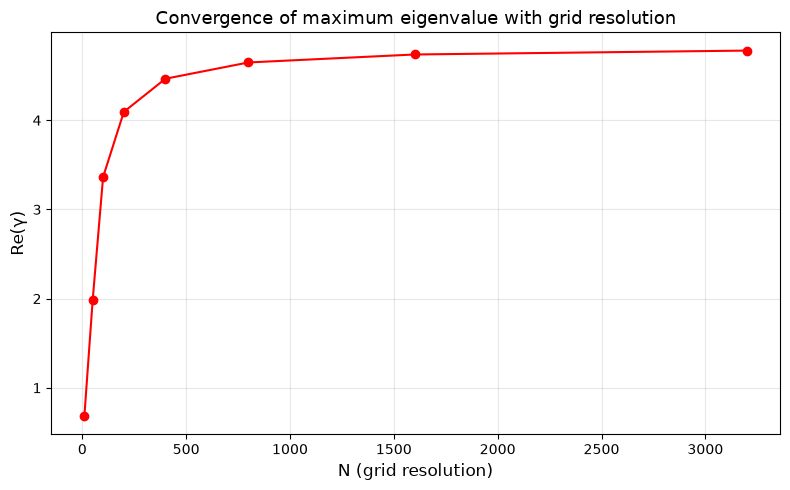

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(N_vals, eigenvalues_list, 'o-', color='red', zorder=5)
plt.xlabel('N (grid resolution)', fontsize=12)
plt.ylabel('Re(γ)', fontsize=12)
plt.title('Convergence of maximum eigenvalue with grid resolution', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()